# 03 — Models, the frozen-feature decision, and training

**Demonstrates:** both architectures (the production `lstm_head` and the trained-from-scratch
`scratch` comparison arm), the measured reasoning behind freezing MobileNetV2 and precomputing
features (ADR-003), class-weighted BCE, the real training curves and TensorBoard activation
histograms from the committed runs, and the MLflow run log.

**Maps to:** report §4.3 (architecture), §4.4 (MLflow/TensorBoard), `docs/SPRINT_PLAN.md` Sprint 1,
`docs/decisions/ADR-003-architecture.md`.


In [1]:
import os
import sys
from pathlib import Path

REPO_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
os.chdir(REPO_ROOT)
sys.path.insert(0, str(REPO_ROOT))
os.environ.setdefault("MLFLOW_ALLOW_FILE_STORE", "true")

import json  # noqa: E402

import matplotlib.pyplot as plt  # noqa: E402

from safestreets.models.factory import build_model, load_model_yaml  # noqa: E402


## The frozen-feature decision (ADR-003)

End-to-end training of the full `scratch` CNN-LSTM measured **8.7 min/epoch** on this machine;
a 30-epoch run is 4.4 hours and a 30-trial Optuna study over it would be 24 to 27 hours, which
does not fit a 1 to 1.5 day deadline. Freezing MobileNetV2 (ImageNet weights) and precomputing
`(N, 16, 1280)` per-frame features dropped the remaining compute to under 2 hours total, measured
the same day on the same machine:

| | |
|---|---|
| MobileNetV2 feature extraction, all 4332 cached clips | **20.2 ms/clip**, 1.5 min total |
| LSTM head on precomputed features, 50 epochs | **1.96 s/epoch**, 1.6 min total |
| 30-trial Optuna study, 25 epochs/trial | **24.5 min** |
| Feature store size | 16x1280 float32 = 80 KB/clip, 0.35 GB total |

This is not a shortcut away from the report: §2.2 names transfer learning from a pretrained CNN
into a recurrent head as the dominant strategy in the cited literature (Mumtaz et al., VGG-19+LSTM;
Traore and Akhloufi, VGG16+BiGRU; Imah et al., ResNet50v2+GRU). The `scratch` CNN-LSTM below is
still built and still trained, as the trained-from-scratch comparison arm, through the live
Phase 3 augmented pipeline (notebook 02).

## Architecture 1: `lstm_head` (production)

Two stacked LSTM layers over precomputed `(16, 1280)` MobileNetV2 features, dropout, sigmoid output.

In [2]:
model_cfg = load_model_yaml("configs/model.yaml")
lstm_head_cfg = dict(model_cfg)
lstm_head_cfg["arch"] = "lstm_head"
lstm_head = build_model(lstm_head_cfg, pos_weight=1.0)
lstm_head.summary()


2026-10-10 17:09:41.880035: I metal_plugin/src/device/metal_device.cc:1154] Metal device set to: Apple M2
2026-10-10 17:09:41.880074: I metal_plugin/src/device/metal_device.cc:296] systemMemory: 16.00 GB
2026-10-10 17:09:41.880081: I metal_plugin/src/device/metal_device.cc:313] maxCacheSize: 5.33 GB
2026-10-10 17:09:41.880101: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:305] Could not identify NUMA node of platform GPU ID 0, defaulting to 0. Your kernel may not have been built with NUMA support.
2026-10-10 17:09:41.880118: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:271] Created TensorFlow device (/job:localhost/replica:0/task:0/device:GPU:0 with 0 MB memory) -> physical PluggableDevice (device: 0, name: METAL, pci bus id: <undefined>)


Model: "lstm_head"


_________________________________________________________________


 Layer (type)                Output Shape              Param #   


 features (InputLayer)       [(None, 16, 1280)]        0         


...

 dense (Dense)               (None, 1)                 65        


Total params: 770881 (2.94 MB)


Trainable params: 770881 (2.94 MB)


Non-trainable params: 0 (0.00 Byte)


_________________________________________________________________


## Architecture 2: `scratch_cnn_lstm` (comparison arm)

Report §4.3's literal architecture: `TimeDistributed` conv blocks with `GlobalAveragePooling2D` (never `Flatten`, which would blow up the LSTM's parameter count on a 112x112 frame, see the module docstring), stacked LSTM, dropout, sigmoid output. Trained end to end on raw pixels through the augmented pipeline.

In [3]:
scratch_cfg = dict(model_cfg)
scratch_cfg["arch"] = "scratch"
scratch_model = build_model(scratch_cfg, pos_weight=1.0)
scratch_model.summary()


Model: "scratch_cnn_lstm"


_________________________________________________________________


 Layer (type)                Output Shape              Param #   


 clips (InputLayer)          [(None, 16, 112, 112, 3   0         


                             )]                                  


...

 dense_2 (Dense)             (None, 1)                 33        


Total params: 221793 (866.38 KB)


Trainable params: 221345 (864.63 KB)


Non-trainable params: 448 (1.75 KB)


_________________________________________________________________


## Class-weighted BCE

`safestreets.training.losses.compute_pos_weight` derives the positive class weight from the actual training label balance, then `safestreets.training.losses.weighted_bce` builds a loss that up-weights whichever class is rarer in that run's training split. Real weight used by the committed baseline run, from its own report:

In [4]:
baseline_report = json.loads(Path("artifacts/reports/train_lstm_head_baseline.json").read_text())
scratch_report = json.loads(Path("artifacts/reports/train_scratch_comparison.json").read_text())
print(f"lstm_head_baseline pos_weight = {baseline_report['pos_weight']:.4f} "
      f"(near 1.0: rwf2000+rlvs train is close to balanced)")
print(f"scratch_comparison pos_weight = {scratch_report['pos_weight']:.4f}")


lstm_head_baseline pos_weight = 0.9973 (near 1.0: rwf2000+rlvs train is close to balanced)
scratch_comparison pos_weight = 1.0000


## Training curves

Real per-epoch history from the committed training-report JSONs (`model.fit`'s own `history.history`, not re-derived or estimated).

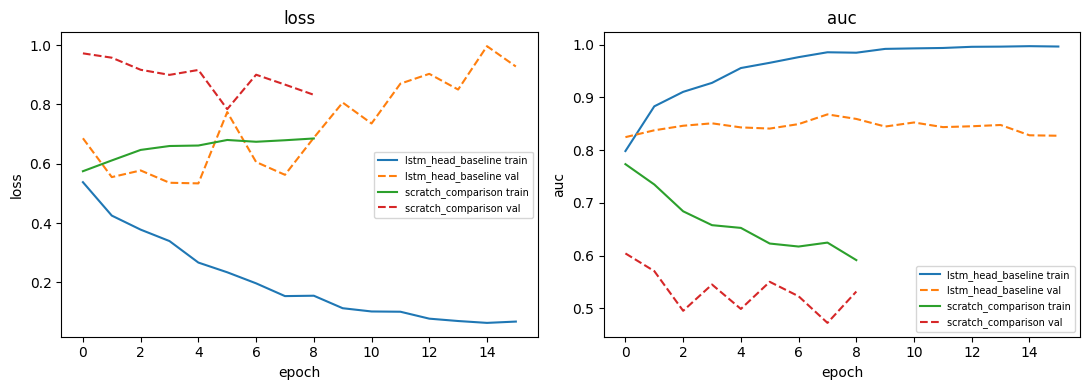

lstm_head_baseline best_val_auc = 0.8679 (16 epochs run before early stopping)
scratch_comparison best_val_auc = 0.6041 (9 epochs run, scaled-down 12-epoch arm, docs/SPRINT_PLAN.md)


In [5]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
reports = [(baseline_report, "lstm_head_baseline"), (scratch_report, "scratch_comparison")]
for ax, metric in zip(axes, ["loss", "auc"]):
    for report, label in reports:
        h = report["history"]
        if metric in h:
            ax.plot(h[metric], label=f"{label} train")
        if f"val_{metric}" in h:
            ax.plot(h[f"val_{metric}"], linestyle="--", label=f"{label} val")
    ax.set_xlabel("epoch")
    ax.set_ylabel(metric)
    ax.set_title(metric)
    ax.legend(fontsize=7)
fig.tight_layout()
plt.show()

n_baseline_epochs = len(baseline_report["history"]["loss"])
n_scratch_epochs = len(scratch_report["history"]["loss"])
print(f"lstm_head_baseline best_val_auc = {baseline_report['best_val_auc']:.4f} "
      f"({n_baseline_epochs} epochs run before early stopping)")
print(f"scratch_comparison best_val_auc = {scratch_report['best_val_auc']:.4f} "
      f"({n_scratch_epochs} epochs run, scaled-down 12-epoch arm, docs/SPRINT_PLAN.md)")


The gap between the two (0.87 vs 0.60 val AUC) is the measured cost of the scaled-down,
12-epoch, trained-from-scratch comparison arm against the frozen-feature production head; it is
not evidence that transfer learning is intrinsically better here, just that this is what each
arm actually reached under this deadline's compute budget.

## TensorBoard: activation histograms

`safestreets.training.callbacks.build_callbacks` attaches a `TensorBoard(histogram_freq=1)` callback, so every epoch's layer weight distributions are logged to `logs/fit/<run_tag>/`. Decoded directly from the real `.tfevents` file below (no screenshot): the production head's final Dense layer kernel, epoch 1 vs. the last logged epoch.

8 histogram tags logged, e.g. ['lstm/lstm_cell/kernel_0/histogram', 'lstm/lstm_cell/recurrent_kernel_0/histogram', 'lstm/lstm_cell/bias_0/histogram']


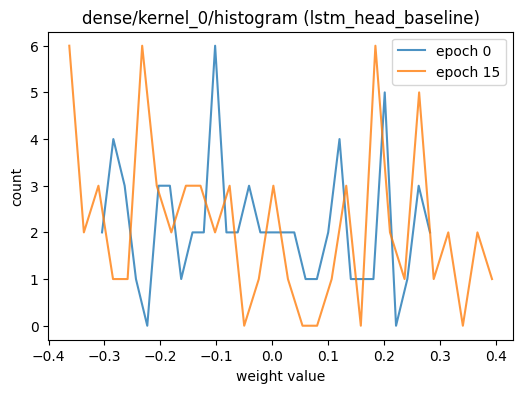

full dashboard: tensorboard --logdir /Users/kanadb/Work/SafeStreets-ViolenceDetection/logs/fit


In [6]:
import tensorflow as tf
from tensorboard.backend.event_processing.event_accumulator import EventAccumulator

ea = EventAccumulator("logs/fit/lstm_head_baseline/train", size_guidance={"tensors": 1000})
ea.Reload()
hist_tags = [t for t in ea.Tags()["tensors"] if t.endswith("/histogram")]
print(f"{len(hist_tags)} histogram tags logged, e.g. {hist_tags[:3]}")

tag = "dense/kernel_0/histogram"
events = ea.Tensors(tag)
fig, ax = plt.subplots(figsize=(6, 4))
for idx, label in [(0, f"epoch {events[0].step}"), (-1, f"epoch {events[-1].step}")]:
    arr = tf.make_ndarray(events[idx].tensor_proto)
    centers = (arr[:, 0] + arr[:, 1]) / 2
    ax.plot(centers, arr[:, 2], label=label, alpha=0.8)
ax.set_xlabel("weight value")
ax.set_ylabel("count")
ax.set_title(f"{tag} (lstm_head_baseline)")
ax.legend()
plt.show()
print(f"full dashboard: tensorboard --logdir {Path('logs/fit').resolve()}")


## MLflow run log

Real rows from the file-store backend `train.py` writes to (`mlruns/`), read live via `mlflow.search_runs`.

In [7]:
import mlflow

mlflow.set_tracking_uri(f"file:{Path('mlruns').resolve()}")
runs = mlflow.search_runs(experiment_names=["safestreets-sprint1"])
cols = ["tags.mlflow.runName", "metrics.best_val_auc", "metrics.val_auc",
        "params.arch", "params.pos_weight"]
runs[[c for c in cols if c in runs.columns]]


/opt/anaconda3/envs/safestreets/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
2026/10/10 17:09:43 INFO mlflow.agent.hint: Load the `instrumenting-with-mlflow-tracing` skill at /opt/anaconda3/envs/safestreets/lib/python3.11/site-packages/mlflow/assistant/skills/instrumenting-with-mlflow-tracing/SKILL.md before writing any tracing code; it ships with this MLflow install. Set MLFLOW_DISABLE_AGENT_HINT=1 to silence this.


,tags.mlflow.runName,metrics.best_val_auc,metrics.val_auc,params.arch,params.pos_weight
0,scratch_comparison,0.604079,0.531755,scratch,1.0
1,lstm_head_baseline,0.867907,0.827381,lstm_head,0.9973386560212908


## Limitations

- The production `lstm_head` never sees augmented input (ADR-003 option 2): its features are
  extracted under the deterministic eval transform, not the live augmented pipeline notebook 02
  demonstrates. This is a recorded, known gap, not a silent one.
- `scratch_comparison`'s 12-epoch run is a scaled-down comparison arm (`docs/SPRINT_PLAN.md` §2),
  not a tuned 30-epoch run; its 0.60 val AUC should be read as "what 12 epochs reaches," not as
  this architecture's ceiling.
